# ICU-Sepsis — MDP demo

This notebook loads the **ICU-Sepsis** environment (a tabular MDP pre-calibrated on MIMIC-III; see the [README](https://github.com/icu-sepsis/icu-sepsis)). Transition/reward/expert-policy matrices are **bundled** in the package (`icu_sepsis/envs/assets/`), and are not rebuilt here from raw CSV files.

- **States**: 716 (including death 713, survival 714, sentinel state 715).
- **Actions**: 25 (5 fluid bins x 5 vasopressor bins), flattened by the Gym wrapper.
- **Goal**: inspect the MDP, estimate policy metrics, and visualize trajectories.

In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from IPython.display import display


def _find_coper_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(12):
        if (p / "icu_sepsis" / "icu_sepsis").is_dir() and (p / "icu_sepsis" / "icu_sepsis_helpers").is_dir():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise RuntimeError(f"Could not find COPER root containing icu_sepsis packages: start={start}")


COPER_ROOT = _find_coper_root(Path.cwd())
PKG_ICU = COPER_ROOT / "icu_sepsis" / "icu_sepsis"
PKG_HELPERS = COPER_ROOT / "icu_sepsis" / "icu_sepsis_helpers"
for pkg in (PKG_ICU, PKG_HELPERS):
    s = str(pkg)
    if s not in sys.path:
        sys.path.insert(0, s)

import icu_sepsis  # registers Sepsis/ICU-Sepsis-v2
from icu_sepsis_helpers.baselines import get_mdp_stats
from icu_sepsis_helpers.utils.mdp import estimate_j_pi, value_iteration

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 1. Environment = MDP loaded from package assets

`gym.make('Sepsis/ICU-Sepsis-v2')` applies a wrapper that **flattens** actions into an integer `0 ... 24`.

In [3]:
ENV_ID = "Sepsis/ICU-Sepsis-v2"
env = gym.make(ENV_ID)
mdp = env.unwrapped

dyn = mdp.dynamics
tx = dyn["tx_mat"]
r_mat = dyn["r_mat"]
d0 = dyn["d_0"]
expert_pi = mdp.expert_policy

meta = mdp.env_metadata
print("env_metadata:", meta)
print("tx_mat shape (S, A, S'):", tx.shape)
print("r_mat shape:", r_mat.shape)
print("d_0 shape:", d0.shape)
print("expert_policy shape:", expert_pi.shape)
print("gamma:", mdp.gamma)

env_metadata: {'n_states': 750, 'n_actions': 25, 'r_survive': 1.0, 'r_death': 0.0, 'threshold': 20, 'seed': 0, 'action_map_method': 'uniform_unweighted'}
tx_mat shape (S, A, S'): (716, 25, 716)
r_mat shape: (716, 25, 716)
d_0 shape: (716,)
expert_policy shape: (716, 25)
gamma: 1.0


### Initial distribution $d_0$ — why not a single state?

The vector **`d_0`** (shape `(716,)`, sums to 1) is the **MDP-level initial-state distribution**: it describes how often **episodes in the cohort** begin in each discrete state. It is **not** meant to say “every patient starts in the same state.”

**Why spread over many states?**  
Each ICU stay is mapped to a sequence of **cluster indices** (k-means on clinical features). The **first decision timestep** of a stay (first “block” of the RL table) falls in **some** cluster $s \in \{0,\ldots,712\}$. Across all stays in MIMIC, those first-step clusters vary, so the **empirical** start distribution puts mass on **many** states. That matches real heterogeneity: patients do not all present in the same physiological bin.

**How it is computed (cohort, not “one patient” in the vector):**  
When the benchmark matrices are built from the RL table (`icu_sepsis_helpers`), each row marks the start of an episode with `bloc == 1`. For that row, the code increments **`d_0[s]`** for the discrete state `s` at that first step. After counting over all episodes, **`d_0` is normalized** to sum to 1. So $d_0(s) \approx$ (number of episodes whose first timestep is in state $s$) / (total episodes).

**For a single real patient:** their trajectory has **one** concrete first discrete state $s$ at the first modeled timestep. The environment’s **`reset()`** samples $S_0 \sim d_0$ to match the **aggregate** benchmark (Monte Carlo over “random episode from the cohort”). To simulate **that** patient only, you would condition on their mapped $s$ (e.g. set or override the initial state in analysis code), which is outside the default Gym `reset` behavior.

In [4]:
rows = [
    {"name": "Sum of P(s'|s,a) over s' (first row)", "value": float(tx[0, 0].sum())},
    {"name": "Initial mass d_0", "value": float(d0.sum())},
    {"name": "Sum pi_expert(s=0, a)", "value": float(expert_pi[0].sum())},
]
display(pd.DataFrame(rows))

sofa = np.asarray(mdp.sofa_scores)
print("SOFA per state — min / max / mean:", float(sofa.min()), float(sofa.max()), float(sofa.mean()))

,name,value
0,"Sum of P(s'|s,a) over s' (first row)",1.0
1,Initial mass d_0,1.0
2,"Sum pi_expert(s=0, a)",1.0


SOFA per state — min / max / mean: 0.0 18.02409638554217 6.828666591575222


## 2. Optimal policy (value iteration) — for comparison

This loop can take a few seconds (716 states, 25 actions).

In [5]:
gamma = 1.0
pi_star, V_star = value_iteration(tx, r_mat, gamma, max_steps=50_000, delta=1e-6)
print("pi_star shape:", pi_star.shape)
print("Example optimal actions (states 0-9):", pi_star[:10])

Value Iteration:   0%|          | 149/50000 [00:06<35:11, 23.61it/s]

pi_star shape: (716,)
Example optimal actions (states 0-9): [20  0  5 15 20  0 10  5  0 10]


## 3. Policy statistics (mean return, episode length)

`get_mdp_stats` in the package uses **50,000** episodes by default. For a faster demo, we set `NUM_EPISODES` lower (increase it for tighter confidence intervals).

In [6]:
NUM_EPISODES = 5_000  # increase (e.g., 50_000) for more stable statistics

n_a = meta["n_actions"]

def policy_random(_s: int) -> int:
    return int(np.random.randint(0, n_a))

def policy_expert(s: int) -> int:
    return int(np.random.choice(expert_pi.shape[1], p=expert_pi[s]))

def policy_optimal(s: int) -> int:
    return int(pi_star[s])

results = {}
for name, pol in [
    ("random", policy_random),
    ("expert", policy_expert),
    ("optimal", policy_optimal),
]:
    j_mean, info = estimate_j_pi(env, pol, num_episodes=NUM_EPISODES, gamma=gamma, desc=name)
    results[name] = {"J_mean": j_mean, **info}

stats_df = pd.DataFrame(results).T
display(stats_df[["J_mean", "mean_ep_len", "stderr"]])

optimal: 100%|██████████| 5000/5000 [00:00<00:00, 6577.96it/s]


,J_mean,mean_ep_len,stderr
random,0.7820,9.4602,0.005839
expert,0.7844,9.0932,0.005816
optimal,0.8814,10.7452,0.004572


In [7]:
# Optional: same output as examples/get_baselines.py (50k episodes, slower)
# stats_pkg = get_mdp_stats(env)
# stats_pkg

## 4. Trajectories — states, SOFA, rewards

A **trajectory** is the sequence of states after `reset` until a terminal state (death / survival / s_inf).

In [8]:
def rollout(env, policy_fn, seed: int | None = None, max_steps: int = 500):
    obs, info = env.reset(seed=seed)
    states = [int(obs)]
    sofas = [float(info["sofa_score"])]
    actions = []
    rewards = []
    for _ in range(max_steps):
        a = policy_fn(obs)
        obs, r, term, trunc, info = env.step(a)
        actions.append(int(a))
        rewards.append(float(r))
        states.append(int(obs))
        sofas.append(float(info["sofa_score"]))
        if term or trunc:
            break
    out = {
        "states": states,
        "sofas": sofas,
        "actions": actions,
        "rewards": rewards,
        "total_reward": sum(rewards),
        "final_state": states[-1],
    }
    return out


def state_label(s: int) -> str:
    if s == 713:
        return "death"
    if s == 714:
        return "survival"
    if s == 715:
        return "s_inf"
    return "clinical"

In [9]:
rng = np.random.default_rng(0)
n_demo = 5
trajectories = []
for i in range(n_demo):
    pol = policy_expert if i % 2 == 0 else policy_random
    tr = rollout(env, pol, seed=int(rng.integers(1_000_000)))
    tr["policy"] = "expert" if pol is policy_expert else "random"
    trajectories.append(tr)

for i, tr in enumerate(trajectories):
    print(f"--- Episode {i} ({tr['policy']}) ---")
    print(f"  len={len(tr['actions'])}, final_state={tr['final_state']} ({state_label(tr['final_state'])}), R={tr['total_reward']}")
    print(f"  first states: {tr['states'][:8]}")

--- Episode 0 (expert) ---
  len=6, final_state=714 (survival), R=1.0
  first states: [119, 119, 119, 410, 189, 189, 714]
--- Episode 1 (random) ---
  len=5, final_state=714 (survival), R=1.0
  first states: [582, 24, 75, 194, 491, 714]
--- Episode 2 (expert) ---
  len=22, final_state=713 (death), R=0.0
  first states: [310, 310, 89, 89, 570, 674, 672, 505]
--- Episode 3 (random) ---
  len=5, final_state=714 (survival), R=1.0
  first states: [326, 676, 676, 676, 676, 714]
--- Episode 4 (expert) ---
  len=12, final_state=714 (survival), R=1.0
  first states: [524, 524, 524, 447, 20, 458, 46, 46]


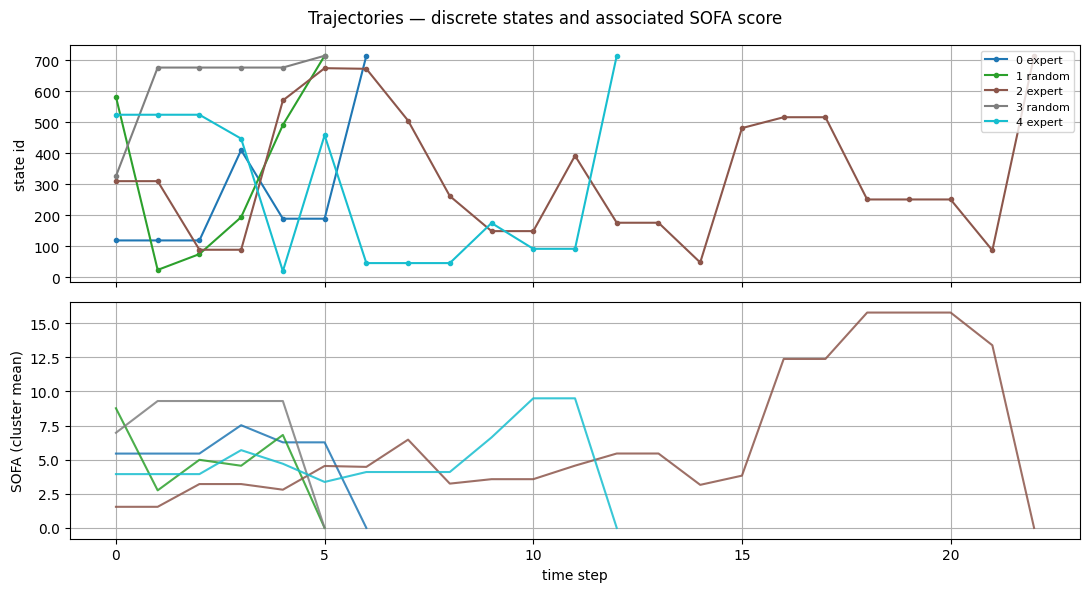

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
colors = plt.cm.tab10(np.linspace(0, 1, n_demo))
for i, tr in enumerate(trajectories):
    t = np.arange(len(tr["states"]))
    axes[0].plot(t, tr["states"], "-o", ms=3, color=colors[i], label=f"{i} {tr['policy']}")
    axes[1].plot(t, tr["sofas"], "-", color=colors[i], alpha=0.85)
axes[0].set_ylabel("state id")
axes[0].legend(loc="upper right", fontsize=8)
axes[1].set_ylabel("SOFA (cluster mean)")
axes[1].set_xlabel("time step")
plt.suptitle("Trajectories — discrete states and associated SOFA score")
plt.tight_layout()
plt.show()

## 5. Histograms — episode lengths and initial states

Small sample for demo speed (increase `N_SAMPLE` if needed).

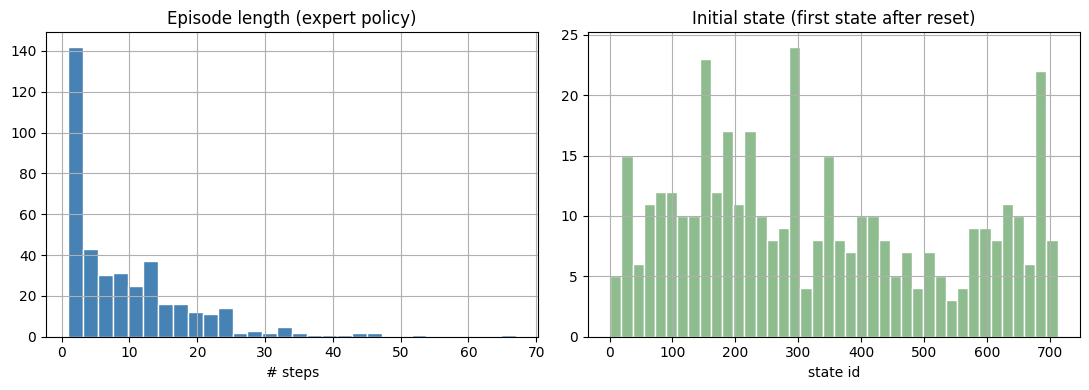

In [11]:
N_SAMPLE = 400
lens_ex = []
inits_ex = []
for k in range(N_SAMPLE):
    tr = rollout(env, policy_expert, seed=10_000 + k)
    lens_ex.append(len(tr["actions"]))
    inits_ex.append(tr["states"][0])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(lens_ex, bins=30, color="steelblue", edgecolor="white")
ax[0].set_title("Episode length (expert policy)")
ax[0].set_xlabel("# steps")
ax[1].hist(inits_ex, bins=40, color="darkseagreen", edgecolor="white")
ax[1].set_title("Initial state (first state after reset)")
ax[1].set_xlabel("state id")
plt.tight_layout()
plt.show()

## 7. UMAP of 716 states + trajectory GIF

We embed **cluster centers** (47-D normalized features per state) with [UMAP](https://umap-learn.readthedocs.io/) into 2D. Points are the **716 MDP states**; color encodes different markers (SOFA, initial mass, expert entropy, admissible-action count).

Then we draw a **long random-policy rollout** (sampled until length ≥ threshold), overlay its path on the SOFA-colored map, and save an animated GIF under `demo_outputs/umap_trajectory_random.gif`.

Install once if needed: `pip install umap-learn pillow` (see `requirements.txt`).

**Expert policy entropy (nats).** Each row `expert_policy[s, :]` is the empirical clinician distribution $\pi_{\mathrm{exp}}(a\mid s)$ over the 25 actions. Its **Shannon entropy** using the **natural logarithm** is measured in **nats** (not bits):

$$H(s) = -\sum_{a=0}^{24} \pi_{\mathrm{exp}}(a\mid s)\,\ln \pi_{\mathrm{exp}}(a\mid s)$$

**Intuition (per state):** $H(s)$ is how *spread out* empirical clinician actions are in that state---low values mean care is concentrated on one or a few actions (predictable); higher values mean more mixing across the 25 bins (heterogeneous practice). $H(s)=0$ only if $\pi_{\mathrm{exp}}(\cdot\mid s)$ is a single action with probability 1.

In code: `ent = -np.sum(expert_pi * np.log(expert_pi + 1e-12), axis=1)` — `np.log` is $\ln$; `1e-12` avoids $\ln 0$ for zero-mass actions.

/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/.venv-coper/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/.venv-coper/lib64/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved figure: /home/charlesv/Desktop/StatisitcalGenetics/pictures/icu_sepsis_umap_states_2x2.png


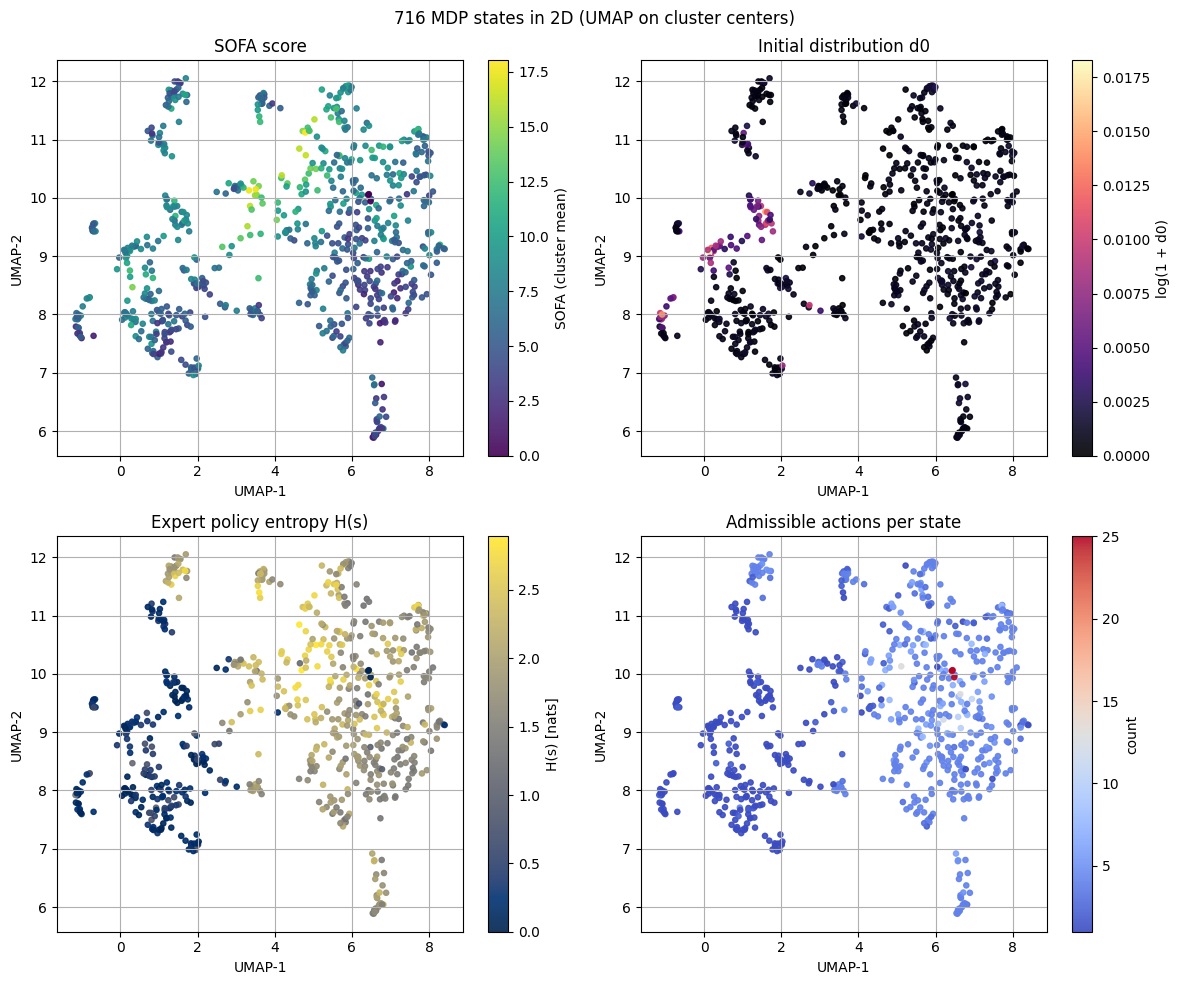

Random rollout: length=46, attempts=102, final_state=714
Saved figure: /home/charlesv/Desktop/StatisitcalGenetics/pictures/icu_sepsis_umap_trajectory_static.png


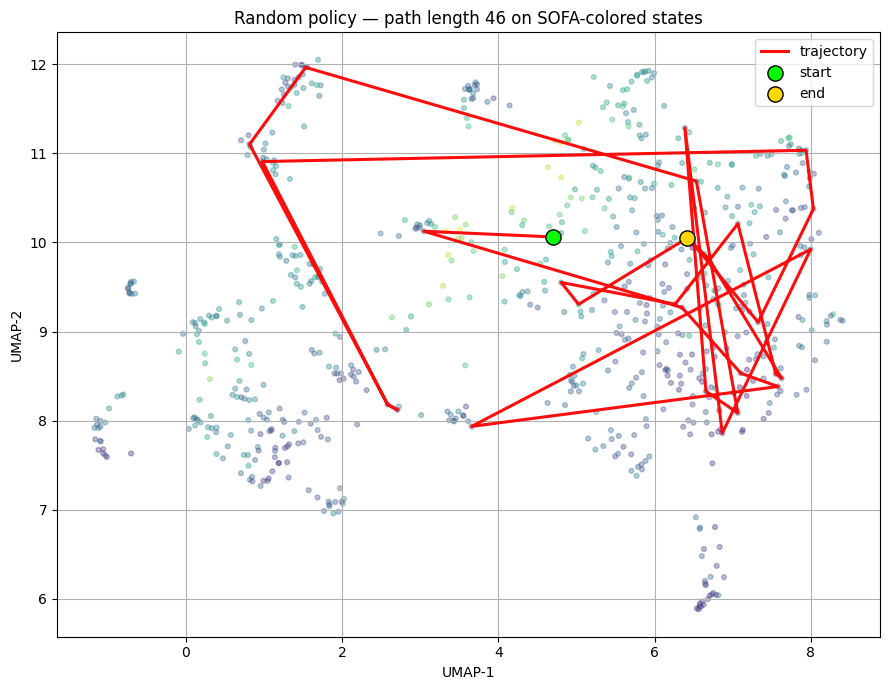

Saved: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/notebooks/demo_outputs/umap_trajectory_random.gif


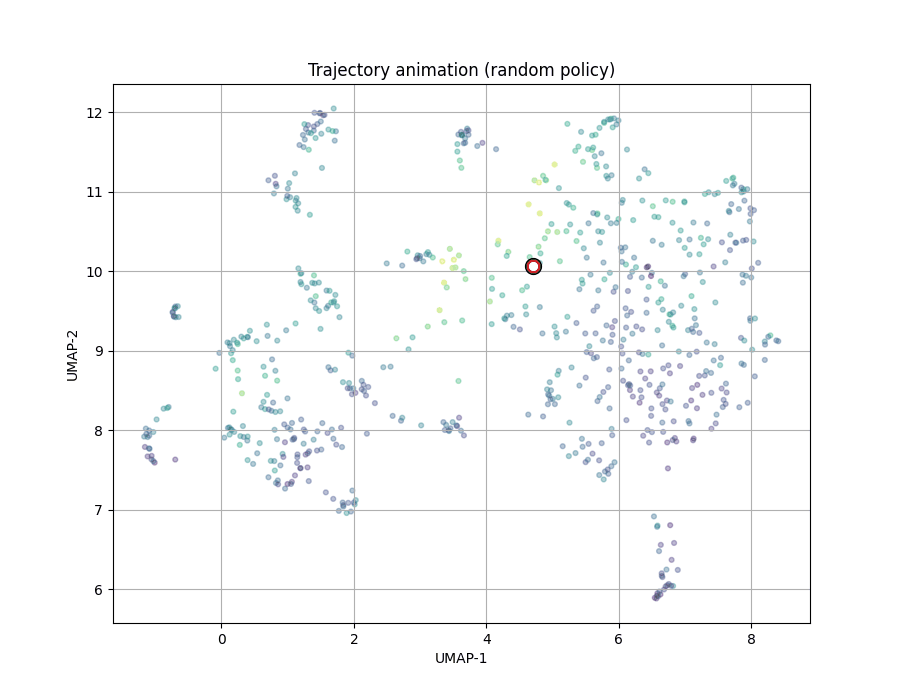

In [12]:
# Requires cells above: env, mdp, meta, expert_pi, d0, rollout()
from pathlib import Path

try:
    import umap

    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    from sklearn.decomposition import PCA

from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image as IPImage

def _resolve_project_pictures_dir() -> Path:
    """Resolve repo-level `pictures/` (e.g. StatisticalGenetics/pictures)."""
    cur = Path.cwd().resolve()
    for _ in range(10):
        cand = cur / "pictures"
        if cand.is_dir():
            return cand
        if cur.parent == cur:
            break
        cur = cur.parent
    fallback = Path.cwd() / "pictures"
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback


PICS_DIR = _resolve_project_pictures_dir()
FIG_UMAP_PANEL = PICS_DIR / "icu_sepsis_umap_states_2x2.png"
FIG_UMAP_TRAJ = PICS_DIR / "icu_sepsis_umap_trajectory_static.png"

# --- 716 x 47 feature matrix (cluster centers) ---
X = np.asarray(mdp.state_cluster_centers)
assert X.shape[0] == 716

sofa_v = np.asarray(mdp.sofa_scores).ravel()
d0_v = np.asarray(d0).ravel()
_aa = mdp.dynamics["admissible_actions"]
adm = np.array([len(_aa[s]) for s in range(716)], dtype=float)
ent = -np.sum(expert_pi * np.log(expert_pi + 1e-12), axis=1)

RNG = 42
if HAS_UMAP:
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric="euclidean",
        random_state=RNG,
    )
    xy = reducer.fit_transform(X)
    dim_label = "UMAP"
else:
    xy = PCA(n_components=2, random_state=RNG).fit_transform(X)
    dim_label = "PCA"

# Optional: mark terminal states 713/714/715 on UMAP (see git history for _overlay_terminal_states)

# --- Static 2x2: different markers ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sc0 = axes[0, 0].scatter(
    xy[:, 0], xy[:, 1], c=sofa_v, cmap="viridis", s=14, alpha=0.9, rasterized=True
)
plt.colorbar(sc0, ax=axes[0, 0], label="SOFA (cluster mean)")
axes[0, 0].set_title("SOFA score")

sc1 = axes[0, 1].scatter(
    xy[:, 0], xy[:, 1], c=np.log1p(d0_v), cmap="magma", s=14, alpha=0.9, rasterized=True
)
plt.colorbar(sc1, ax=axes[0, 1], label="log(1 + d0)")
axes[0, 1].set_title("Initial distribution d0")

sc2 = axes[1, 0].scatter(
    xy[:, 0], xy[:, 1], c=ent, cmap="cividis", s=14, alpha=0.9, rasterized=True
)
plt.colorbar(sc2, ax=axes[1, 0], label="H(s) [nats]")
axes[1, 0].set_title("Expert policy entropy H(s)")

sc3 = axes[1, 1].scatter(
    xy[:, 0], xy[:, 1], c=adm, cmap="coolwarm", s=14, alpha=0.9, rasterized=True
)
plt.colorbar(sc3, ax=axes[1, 1], label="count")
axes[1, 1].set_title("Admissible actions per state")

for ax in axes.ravel():
    ax.set_xlabel(f"{dim_label}-1")
    ax.set_ylabel(f"{dim_label}-2")
plt.suptitle(f"716 MDP states in 2D ({dim_label} on cluster centers)")
plt.tight_layout()
PICS_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_UMAP_PANEL, dpi=200, bbox_inches="tight")
print(f"Saved figure: {FIG_UMAP_PANEL.resolve()}")
plt.show()

# --- Long random trajectory (retry until length >= min_len) ---
n_a = int(meta["n_actions"])


def policy_random_long(_s: int) -> int:
    return int(np.random.randint(0, n_a))


def sample_long_rollout(
    policy_fn, min_len: int = 40, max_tries: int = 1_000, base_seed: int = 12345
):
    rng = np.random.default_rng(base_seed)
    best = None
    for t in range(max_tries):
        tr = rollout(env, policy_fn, seed=int(rng.integers(1_000_000_000)))
        if best is None or len(tr["actions"]) > len(best["actions"]):
            best = tr
        if len(tr["actions"]) >= min_len:
            return tr, t + 1
    return best, max_tries


long_tr, n_tries = sample_long_rollout(
    policy_random_long, min_len=42, max_tries=1_200, base_seed=2026
)
print(
    f"Random rollout: length={len(long_tr['actions'])}, attempts={n_tries}, "
    f"final_state={long_tr['final_state']}"
)

path_xy = np.stack([xy[s] for s in long_tr["states"]], axis=0)

# --- Static overlay on SOFA map ---
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(xy[:, 0], xy[:, 1], c=sofa_v, cmap="viridis", s=12, alpha=0.35, rasterized=True)
ax.plot(path_xy[:, 0], path_xy[:, 1], "r-", lw=2.2, alpha=0.95, label="trajectory")
ax.scatter(
    path_xy[0, 0],
    path_xy[0, 1],
    c="lime",
    s=120,
    edgecolors="k",
    zorder=6,
    label="start",
)
ax.scatter(
    path_xy[-1, 0],
    path_xy[-1, 1],
    c="gold",
    s=120,
    edgecolors="k",
    zorder=6,
    label="end",
)
ax.set_title(f"Random policy — path length {len(long_tr['actions'])} on SOFA-colored states")
ax.set_xlabel(f"{dim_label}-1")
ax.set_ylabel(f"{dim_label}-2")
ax.legend(loc="upper right")
plt.tight_layout()
fig.savefig(FIG_UMAP_TRAJ, dpi=200, bbox_inches="tight")
print(f"Saved figure: {FIG_UMAP_TRAJ.resolve()}")
plt.show()

# --- GIF: path revealed step by step ---
out_dir = COPER_ROOT / "icu_sepsis" / "demo_outputs"
out_dir.mkdir(parents=True, exist_ok=True)
gif_path = out_dir / "umap_trajectory_random.gif"

fig_g, ax_g = plt.subplots(figsize=(9, 7))
ax_g.scatter(xy[:, 0], xy[:, 1], c=sofa_v, cmap="viridis", s=12, alpha=0.35, rasterized=True)
(line,) = ax_g.plot([], [], "r-", lw=2.8, alpha=0.95)
start_sc = ax_g.scatter([], [], c="lime", s=130, edgecolors="k", zorder=7)
cur_sc = ax_g.scatter([], [], c="white", s=70, edgecolors="red", linewidths=1.5, zorder=8)
ax_g.set_xlabel(f"{dim_label}-1")
ax_g.set_ylabel(f"{dim_label}-2")
ax_g.set_title("Trajectory animation (random policy)")

states_seq = long_tr["states"]
path_full = np.stack([xy[s] for s in states_seq], axis=0)


def animate(frame: int):
    k = frame + 1
    seg = path_full[:k]
    line.set_data(seg[:, 0], seg[:, 1])
    start_sc.set_offsets(seg[[0]])
    cur_sc.set_offsets(seg[[-1]])
    return line, start_sc, cur_sc


anim = FuncAnimation(
    fig_g,
    animate,
    frames=len(states_seq),
    interval=110,
    blit=False,
)
anim.save(gif_path, writer=PillowWriter(fps=9))
plt.close(fig_g)
print(f"Saved: {gif_path.resolve()}")
display(IPImage(filename=str(gif_path)))


## 6. Rebuild the MDP from MIMIC (out of scope for this demo)

To recompute matrices from raw data: run the **AI Clinician** pipeline -> cohort table -> `icu_sepsis_helpers.build.build_mimic_params` (see `examples/build_mimic_demo.py` and the repo README).

To **evaluate COPER** in this MDP: map model outputs to a **policy** $\pi(a\mid s)$ over the 25 actions (or per-state logits aligned with ICU-Sepsis clustering), then reuse `estimate_j_pi` as above.

## 8. Simulated rollout statistics (Gym episodes)

These numbers are **not** raw MIMIC row counts: each line is one **`env.reset()` → `step` until `terminated` or `truncated`** under the bundled MDP. We report how many **actions** (steps) were taken, total count of such **trajectories**, mean episode **return** (0/1 survival reward in this env), and how often episodes end in **death (713)**, **survival (714)**, **s_inf (715)**, or another state (e.g. hit `max_episode_steps`).

In [13]:
from collections import Counter

# Requires: env, rollout, policy_expert, policy_random, meta (run sections 1–4 first)
N_ROLLOUT_STATS = 3_000  # increase for tighter Monte Carlo estimates
rng_stats = np.random.default_rng(7)


def summarize_rollouts(policy_fn, label: str, n: int) -> dict:
    lengths: list[int] = []
    rewards: list[float] = []
    finals: list[int] = []
    for _ in range(n):
        tr = rollout(env, policy_fn, seed=int(rng_stats.integers(1_000_000_000)))
        lengths.append(len(tr["actions"]))
        rewards.append(float(tr["total_reward"]))
        finals.append(int(tr["final_state"]))
    fc = Counter(finals)
    n_term = fc.get(713, 0) + fc.get(714, 0) + fc.get(715, 0)
    return {
        "policy": label,
        "n_trajectories": n,
        "total_actions": int(sum(lengths)),
        "mean_actions_per_ep": float(np.mean(lengths)),
        "std_actions_per_ep": float(np.std(lengths)),
        "mean_return": float(np.mean(rewards)),
        "pct_death_713": 100.0 * fc.get(713, 0) / n,
        "pct_survival_714": 100.0 * fc.get(714, 0) / n,
        "pct_s_inf_715": 100.0 * fc.get(715, 0) / n,
        "pct_other_final": 100.0 * (n - n_term) / n,
    }


stats_rows = [
    summarize_rollouts(policy_expert, "expert", N_ROLLOUT_STATS),
    summarize_rollouts(policy_random, "random", N_ROLLOUT_STATS),
]
display(pd.DataFrame(stats_rows).set_index("policy"))

,n_trajectories,total_actions,mean_actions_per_ep,std_actions_per_ep,mean_return,pct_death_713,pct_survival_714,pct_s_inf_715,pct_other_final
policy,,,,,,,,,
expert,3000,28121,9.373667,9.658504,0.792333,20.766667,79.233333,0.0,0.0
random,3000,28392,9.464000,9.721936,0.773667,22.633333,77.366667,0.0,0.0
